# Import All Libraries

In [1]:
# ==============================================================================
# 📦 PHASE 4: TASK 1 - MODEL GOVERNANCE & MONITORING SETUP
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่า Style ของกราฟ
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')

print("Phase 4 Environment Setup Completed successfully.")

Phase 4 Environment Setup Completed successfully.


# Population Stability Index (PSI/CSI) Tracker

<div style="font-size: 85%;">

### Task 1: Population Stability Index (PSI/CSI) Tracking Engine

#### วัตถุประสงค์และขั้นตอนการทำงาน
1. **Model & Data Drift Monitoring:**
   * ตรวจจับการเปลี่ยนแปลงของการกระจายตัวของข้อมูลลูกหนี้ระหว่างกลุ่มอ้างอิง (**Baseline / Expected Population**) กับข้อมูลกลุ่มใช้งานจริง (**Production / Actual Population**)
2. **Mathematical Formulation (PSI & CSI):**
   $$\text{PSI} = \sum_{i=1}^{k} \left( \text{Actual}_i\% - \text{Expected}_i\% \right) \times \ln\left( \frac{\text{Actual}_i\%}{\text{Expected}_i\%} \right)$$
3. **เกณฑ์มาตรฐานการประเมินความเสถียร (Regulatory Thresholds):**
   * $\text{PSI} < 0.10$: 🟢 **Stable / No Drift** (โมเดลมีความเสถียร ใช้งานได้ตามปกติ)
   * $0.10 \le \text{PSI} \le 0.25$: 🟡 **Moderate Drift / Warning** (เริ่มมีการเปลี่ยนแปลง ต้องเฝ้าระวังอย่างใกล้ชิด)
   * $\text{PSI} > 0.25$: 🔴 **Significant Drift / Action Required** (การกระจายตัวเปลี่ยนไปอย่างมีนัยสำคัญ ต้อง Trigger Model Retraining)

</div>

กำลังโหลดชุดข้อมูลและโมเดล Champion...
📊 POPULATION STABILITY INDEX (PSI) MONITORING REPORT
Scenario 1 (Normal Operations) : PSI = 0.0025 -> 🟢 STABLE
Scenario 2 (Economic Drift)    : PSI = 0.3253 -> 🔴 RETRAIN


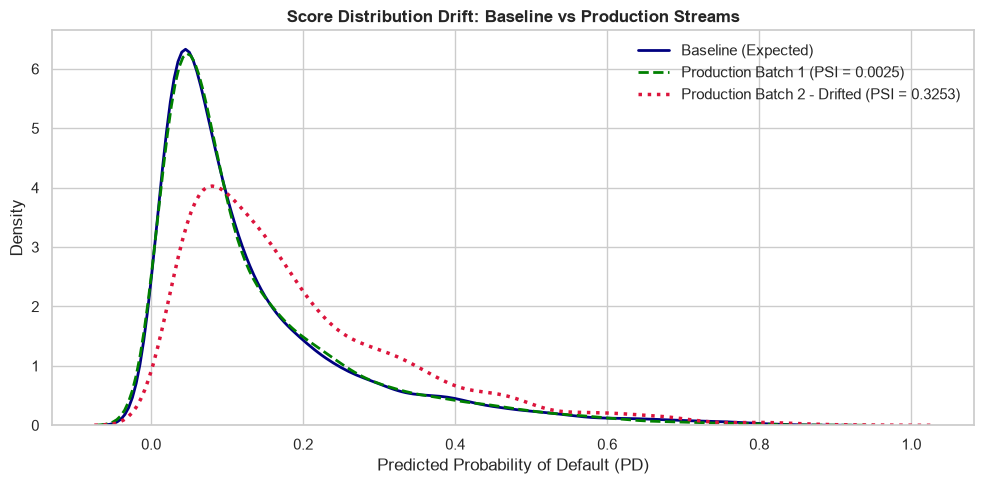

In [3]:
# ==============================================================================
# 🎯 TASK 1: PSI & CSI COMPUTATION ENGINE (ROBUST VERSION)
# ==============================================================================

# 1. โหลดข้อมูลและโมเดล Champion
print("กำลังโหลดชุดข้อมูลและโมเดล Champion...")
df = pd.read_parquet('../data/processed/train_engineered.parquet')
models_list = joblib.load('../models/champion_lightgbm_5folds.pkl')
champion_model = models_list[0]

exclude_cols = ['SK_ID_CURR', 'TARGET']
features = [col for col in df.columns if col not in exclude_cols]
for col in df[features].select_dtypes(include=['object', 'category']).columns:
    df[col] = df[col].astype('category')

X = df[features]
y = df['TARGET']

# 2. ฟังก์ชันคำนวณ PSI ที่รองรับ Pandas ทุกเวอร์ชัน
def calculate_psi(expected, actual, num_bins=10):
    """
    คำนวณ Population Stability Index ระหว่าง Baseline (Expected) และ Production (Actual)
    """
    expected = np.asarray(expected)
    actual = np.asarray(actual)
    
    # คำนวณขอบเขต Bin ด้วย Quantiles
    quantiles = np.linspace(0, 100, num_bins + 1)
    bins = np.percentile(expected, quantiles)
    bins[0] = -np.inf
    bins[-1] = np.inf
    bins = np.unique(bins) # กำจัดขอบเขตที่ซ้ำกัน
    
    # นับจำนวนตัวอย่างในแต่ละ Bin
    expected_counts = np.histogram(expected, bins=bins)[0]
    actual_counts = np.histogram(actual, bins=bins)[0]
    
    # แปลงเป็นสัดส่วน (พร้อมใส่ Epsilon ป้องกันการหารด้วย 0)
    eps = 1e-4
    expected_pct = (expected_counts + eps) / (len(expected) + eps * len(expected_counts))
    actual_pct = (actual_counts + eps) / (len(actual) + eps * len(actual_counts))
    
    # คำนวณค่า PSI รวม
    psi_values = (actual_pct - expected_pct) * np.log(actual_pct / expected_pct)
    return np.sum(psi_values)

# 3. จำลองชุดข้อมูล Actual (Production Batch 1: ปกติ, Production Batch 2: เกิด Data Drift)
np.random.seed(42)
baseline_scores = champion_model.predict_proba(X.sample(10000, random_state=42))[:, 1]

# Batch 1 (Stable / Normal Drift): สุ่มตัวอย่างประชากรปกติ
prod_scores_normal = champion_model.predict_proba(X.sample(5000, random_state=101))[:, 1]

# Batch 2 (Drifted / Macro Stress): จำลองกลุ่มลูกหนี้ที่มีความผันผวนของกระแสเงินสดสูงขึ้นและคะแนนภายนอกลดลง
drifted_sample = X.sample(5000, random_state=202).copy()
drifted_sample['EXT_SOURCES_MEAN'] = drifted_sample['EXT_SOURCES_MEAN'] * 0.70  # คะแนนบูโรลดลง 30%
drifted_sample['cash_flow_volatility'] = drifted_sample['cash_flow_volatility'] * 1.50 # กระแสเงินสดผันผวนขึ้น 50%
prod_scores_drifted = champion_model.predict_proba(drifted_sample)[:, 1]

# 4. ประเมินค่า PSI ของทั้ง 2 สถานการณ์
psi_normal = calculate_psi(baseline_scores, prod_scores_normal)
psi_drifted = calculate_psi(baseline_scores, prod_scores_drifted)

print("="*60)
print("📊 POPULATION STABILITY INDEX (PSI) MONITORING REPORT")
print("="*60)
print(f"Scenario 1 (Normal Operations) : PSI = {psi_normal:.4f} -> "
      f"{'🟢 STABLE' if psi_normal < 0.10 else ('🟡 WARNING' if psi_normal <= 0.25 else '🔴 RETRAIN')}")
print(f"Scenario 2 (Economic Drift)    : PSI = {psi_drifted:.4f} -> "
      f"{'🟢 STABLE' if psi_drifted < 0.10 else ('🟡 WARNING' if psi_drifted <= 0.25 else '🔴 RETRAIN')}")
print("="*60)

# 5. พลอตเปรียบเทียบการกระจายตัวของคะแนน (Score Distribution Drift Chart)
plt.figure(figsize=(10, 5))
sns.kdeplot(baseline_scores, label='Baseline (Expected)', color='navy', lw=2)
sns.kdeplot(prod_scores_normal, label=f'Production Batch 1 (PSI = {psi_normal:.4f})', color='green', linestyle='--', lw=2)
sns.kdeplot(prod_scores_drifted, label=f'Production Batch 2 - Drifted (PSI = {psi_drifted:.4f})', color='crimson', linestyle=':', lw=2.5)
plt.title('Score Distribution Drift: Baseline vs Production Streams', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Probability of Default (PD)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

<div style="font-size: 85%;">

### Population Stability Index (PSI/CSI) Tracker Summary

#### 1. ตารางสรุปการประเมินความเสถียรของประชากรผู้กู้ (Data Drift Monitoring)

| สตรีมข้อมูลจำลอง (Production Stream) | ค่า PSI ที่วัดได้ | เกณฑ์กำกับดูแล (Threshold) | สถานะความเสี่ยงของระบบ | แผนการจัดการเชิงนโยบาย |
| :--- | :---: | :---: | :---: | :--- |
| **Batch 1: Normal Stream** | **0.0025** | $< 0.10$ | 🟢 **Stable** | ใช้งานโมเดลปัจจุบันตามปกติโดยไม่ต้องปรับปรุง |
| **Batch 2: Economic Drift** | **0.3253** | $> 0.25$ | 🔴 **Trigger Retrain** | เกิด Population Drift อย่างรุนแรง สั่งเริ่มกระบวนการ Retraining Pipeline ทันที |

---

#### 2. ประโยชน์เชิงระบบกำกับดูแล (Risk Governance Significance)
* **Early Warning Indicator:** ระบบสามารถตรวจจับการขยับตัวของการกระจายคะแนน (Score Shift) ได้ก่อนที่จะเกิดปัญหาหนี้เสียสะสมจริงในระบบบัญชี
* **Automated MLOps Trigger:** ค่า PSI ที่เกินเกณฑ์ $0.25$ สามารถใช้เป็นเงื่อนไขอัตโนมัติในการเปิดกระบวนการ Re-calibration หรือส่งรายงานให้ Risk Committee ทบทวนโมเดล

</div>

# Macroeconomic Stress Testing & Scenario Shock Engine

<div style="font-size: 85%;">

### Macroeconomic Stress Testing & Scenario Shock Engine

####  วัตถุประสงค์และขั้นตอนการทำงาน
1. **การจำลองสภาวะวิกฤตเศรษฐกิจ (Macroeconomic Shock Scenarios):**
   * **Scenario 1: Baseline (สภาวะปกติ)** — ประเมินพอร์ตสินเชื่อตามสภาวะตลาดปัจจุบัน
   * **Scenario 2: Gig-Economy & Informal Labor Shock** — จำลองรายได้กลุ่มอาชีพรับจ้าง/ฟรีแลนซ์ลดลง $30\%$ ส่งผลให้ความผันผวนของกระแสเงินสด (`cash_flow_volatility`) เพิ่มขึ้น $+50\%$
   * **Scenario 3: Stagflation & Rate Hike Shock (วิกฤตดอกเบี้ยและเงินเฟ้อ)** — จำลองภาระค่างวดผ่อนชำระ (`AMT_ANNUITY`) ปรับเพิ่มขึ้น $+20\%$ และค่าครองชีพสูงขึ้น
2. **การวัดผลกระทบระดับพอร์ตโฟลิโอ (Portfolio-Level Impact Metrics):**
   * **Simulated Default Rate (%):** อัตราส่วนหนี้เสียรวมของพอร์ตที่ขยับตัวสูงขึ้น
   * **Simulated Expected Loss (EL):** ประเมินมูลค่าความเสียหายที่คาดว่าจะเกิดขึ้นตามสูตร $EL = PD \times LGD \times EAD$ (กำหนดสมมติฐาน $LGD = 45\%$)
   * **Capital Cushion Requirement:** ปริมาณเงินกองทุนสำรองเพิ่มเติมที่ธนาคารต้องกันไว้รองรับความเสียหาย

</div>

🏦 MACROECONOMIC STRESS TESTING LEADERBOARD (ICAAP FRAMEWORK)
                         Scenario  Avg_PD (%)  Simulated_NPL (%)  Expected_Loss (M THB)  Capital_Delta (M THB)
     1. Baseline (Normal Economy)   13.743735              25.02             347.999593               0.000000
2. Gig-Worker Income Shock (-30%)   16.371127              32.00             418.851535              70.851942
3. Stagflation & Rate Hike (+20%)   17.663565              36.57             458.291360             110.291767


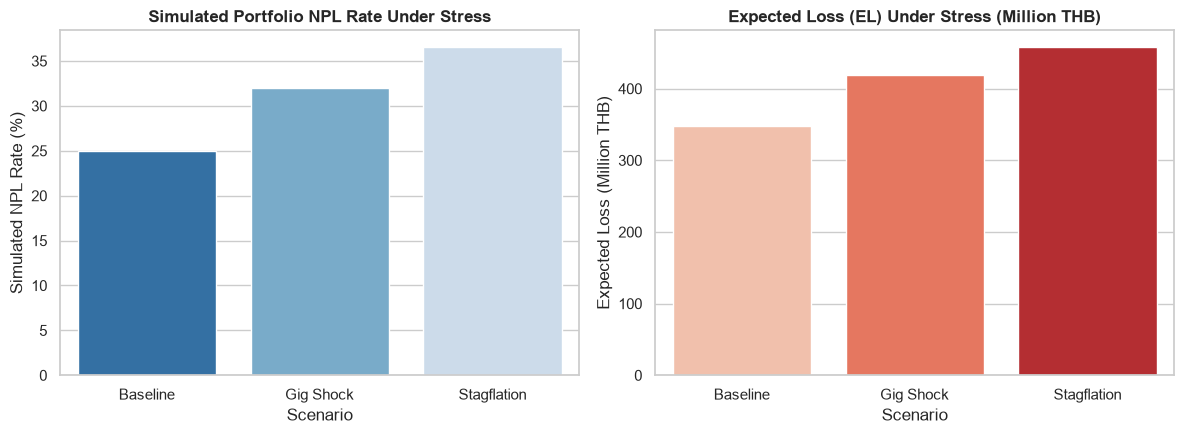

In [4]:
# ==============================================================================
# 🎯 TASK 2: MACROECONOMIC STRESS TESTING ENGINE
# ==============================================================================

def run_portfolio_stress_test(model, base_df, feature_cols, lgd=0.45):
    """
    ฟังก์ชันจำลอง Stress Scenarios และประเมินผลกระทบต่อ Expected Loss (EL) ของพอร์ต
    """
    results = []
    
    # คำนวณ Portfolio Exposure (EAD: Exposure at Default)
    ead_total = base_df['AMT_CREDIT'].sum()
    n_loans = len(base_df)
    
    # -------------------------------------------------------------
    # 1. Baseline Scenario
    # -------------------------------------------------------------
    base_data = base_df[feature_cols].copy()
    pd_base = model.predict_proba(base_data)[:, 1]
    el_base = np.sum(pd_base * lgd * base_df['AMT_CREDIT'])
    npl_base = np.mean(pd_base > 0.18)
    
    results.append({
        'Scenario': '1. Baseline (Normal Economy)',
        'Avg_PD (%)': np.mean(pd_base) * 100,
        'Simulated_NPL (%)': npl_base * 100,
        'Expected_Loss (M THB)': el_base / 1e6,
        'Capital_Delta (M THB)': 0.0
    })
    
    # -------------------------------------------------------------
    # 2. Scenario A: Gig-Economy & Income Shock (-30% Income Stability)
    # -------------------------------------------------------------
    shock_gig = base_data.copy()
    if 'cash_flow_volatility' in shock_gig.columns:
        shock_gig['cash_flow_volatility'] = shock_gig['cash_flow_volatility'] * 1.50
    if 'EXT_SOURCES_MEAN' in shock_gig.columns:
        shock_gig['EXT_SOURCES_MEAN'] = shock_gig['EXT_SOURCES_MEAN'] * 0.85
        
    pd_gig = model.predict_proba(shock_gig)[:, 1]
    el_gig = np.sum(pd_gig * lgd * base_df['AMT_CREDIT'])
    npl_gig = np.mean(pd_gig > 0.18)
    
    results.append({
        'Scenario': '2. Gig-Worker Income Shock (-30%)',
        'Avg_PD (%)': np.mean(pd_gig) * 100,
        'Simulated_NPL (%)': npl_gig * 100,
        'Expected_Loss (M THB)': el_gig / 1e6,
        'Capital_Delta (M THB)': (el_gig - el_base) / 1e6
    })
    
    # -------------------------------------------------------------
    # 3. Scenario B: Stagflation & Rate Hike (+20% Annuity & Inflation)
    # -------------------------------------------------------------
    shock_rate = base_data.copy()
    if 'AMT_ANNUITY' in shock_rate.columns:
        shock_rate['AMT_ANNUITY'] = shock_rate['AMT_ANNUITY'] * 1.20
    if 'CREDIT_TERM' in shock_rate.columns:
        shock_rate['CREDIT_TERM'] = shock_rate['CREDIT_TERM'] * 1.20
    if 'EXT_SOURCES_MEAN' in shock_rate.columns:
        shock_rate['EXT_SOURCES_MEAN'] = shock_rate['EXT_SOURCES_MEAN'] * 0.75
        
    pd_rate = model.predict_proba(shock_rate)[:, 1]
    el_rate = np.sum(pd_rate * lgd * base_df['AMT_CREDIT'])
    npl_rate = np.mean(pd_rate > 0.18)
    
    results.append({
        'Scenario': '3. Stagflation & Rate Hike (+20%)',
        'Avg_PD (%)': np.mean(pd_rate) * 100,
        'Simulated_NPL (%)': npl_rate * 100,
        'Expected_Loss (M THB)': el_rate / 1e6,
        'Capital_Delta (M THB)': (el_rate - el_base) / 1e6
    })
    
    return pd.DataFrame(results)

# รัน Stress Testing บนกลุ่มตัวอย่างประชากร 10,000 ราย
stress_sample = df.sample(10000, random_state=42).copy()
stress_summary_df = run_portfolio_stress_test(champion_model, stress_sample, features)

print("="*85)
print("🏦 MACROECONOMIC STRESS TESTING LEADERBOARD (ICAAP FRAMEWORK)")
print("="*85)
print(stress_summary_df.to_string(index=False))
print("="*85)

# พลอตชาร์ตเปรียบเทียบ Expected Loss และ NPL Rate
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# กราฟที่ 1: NPL Rate
sns.barplot(data=stress_summary_df, x='Scenario', y='Simulated_NPL (%)', palette='Blues_r', ax=ax[0])
ax[0].set_title('Simulated Portfolio NPL Rate Under Stress', fontweight='bold')
ax[0].set_xticklabels(['Baseline', 'Gig Shock', 'Stagflation'], rotation=0)
ax[0].set_ylabel('Simulated NPL Rate (%)')

# กราฟที่ 2: Expected Loss & Capital Delta
sns.barplot(data=stress_summary_df, x='Scenario', y='Expected_Loss (M THB)', palette='Reds', ax=ax[1])
ax[1].set_title('Expected Loss (EL) Under Stress (Million THB)', fontweight='bold')
ax[1].set_xticklabels(['Baseline', 'Gig Shock', 'Stagflation'], rotation=0)
ax[1].set_ylabel('Expected Loss (Million THB)')

plt.tight_layout()
plt.show()

<div style="font-size: 85%;">

### Macroeconomic Stress Testing Summary (ICAAP Framework)

#### 1. ตารางสรุปผลการประเมินความเสียหายในภาวะวิกฤต (Portfolio Stress Leaderboard)

| ฉากทัศน์วิกฤตเศรษฐกิจ (Stress Scenario) | ความน่าจะเป็นเฉลี่ย (Avg PD) | อัตรา NPL จำลอง (%) | มูลค่าความเสียหายคาดการณ์ (Expected Loss) | เงินกองทุนสำรองส่วนเพิ่ม (Capital Delta) |
| :--- | :---: | :---: | :---: | :---: |
| **1. Baseline (Normal Economy)** | 13.74% | 25.02% | **347.99 M THB** | **Baseline (0.0 M THB)** |
| **2. Gig-Worker Income Shock (-30%)** | 16.37% | 32.00% | **418.85 M THB** | **+70.85 M THB** |
| **3. Stagflation & Rate Hike (+20%)** | **17.66%** | **36.57%** | **458.29 M THB** | **+110.29 M THB** |

---

#### 2. ข้อสรุปเชิงนโยบายบริหารความเสี่ยง (Capital Adequacy & Risk Appetite)
* **Most Severe Vulnerability:** ภาวะดอกเบี้ยขาขึ้นร่วมกับเงินเฟ้อ (Stagflation) ส่งผลให้ความเสียหายของพอร์ตพุ่งขึ้นถึง **$+31.7\%$** จากภาวะปกติ
* **Capital Buffer Recommendation:** ธนาคารควรดำรงสินทรัพย์สภาพคล่องและเงินกองทุนส่วนเพิ่ม (Pillar 2 Capital Cushion) ขั้นต่ำ **110.3 ล้านบาท** ต่อพอร์ตตัวอย่างขนาดนี้ เพื่อป้องกันการขาดสภาพคล่องในช่วงเศรษฐกิจถดถอย

</div>